# GAT Electrophilicity — MAA prediction


Summary:
- **Atomic features**: 12 continuous dimensions + one-hot (identical to MPNN)
- **Bond features**: 6 dimensions (type, conjugation, ring)
- **Split**: molecule-level, 80/10/10, `numpy.default_rng(42)`, canonicalized SMILES, zero-overlap verification
- **Normalization**: computed on training set only
- **Loss function**: `SmoothL1Loss` (Huber)
- **Batch size** : 64 
- **Early-stopping patience**: 15 epochs


In [ ]:
!pip install pandas numpy rdkit torch torch-geometric scikit-learn matplotlib tqdm -q

In [3]:
import os
import glob
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv          # GATv2 supporte edge_attr
from torch_geometric.loader import DataLoader

from rdkit import Chem
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


c:\Users\felic\Desktop\AIforChemistry\.conda\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] La procédure spécifiée est introuvable
  import torch_geometric.typing
c:\Users\felic\Desktop\AIforChemistry\.conda\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 127] La procédure spécifiée est introuvable
  import torch_geometric.typing
c:\Users\felic\Desktop\AIforChemistry\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

import urllib.request
import tarfile

# ── Reproducibility ─────────────────────────────────────

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

url          = "https://sid.erda.dk/share_redirect/c7LF5NaYvH"
archive_name = "data.tar.xz"
path_elec    = "data/QMdata4ML/df_elec.csv.gz"

if not os.path.exists(path_elec):
    if not os.path.exists(archive_name):
        print("Downloading archive (~1.1 GB)...")
        urllib.request.urlretrieve(url, archive_name)
        print("Download complete.")
    print("Extracting archive...")
    with tarfile.open(archive_name, "r:xz") as tar:
        tar.extractall()
    print("Extraction complete.")

df = pd.read_csv(path_elec)
print(f"Loaded {len(df)} rows.")
try:
    display(df.head())
except NameError:
    print(df.head())


# ── Cleanup without MAA filter ───────────────────────────────────────────────
df['MAA_values'] = pd.to_numeric(df['MAA_values'], errors='coerce')
df = df.dropna(subset=['smiles', 'MAA_values', 'elec_sites'])
df['elec_sites'] = df['elec_sites'].astype(int)
df = df.reset_index(drop=True)
print(f"Rows after cleanup: {len(df)}")


Loaded 534119 rows.


,Unnamed: 0,smiles,elec_sites,elec_names,MAA_values,elec_GCS_3_cm5,Set
0,0,NOCc1cccc(I)c1,3,double_bond,90.348433,"[-0.01706, 0.12057, -0.11146, -0.08969, 0.0, -...",Train_fold5
1,1,NOCc1cccc(I)c1,4,double_bond,94.924314,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold2
2,2,NOCc1cccc(I)c1,5,double_bond,91.330269,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold3
3,3,NOCc1cccc(I)c1,6,double_bond,102.683928,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold1
4,4,NOCc1cccc(I)c1,7,double_bond,276.204538,"[0.01492, 0.00479, -0.11146, -0.10499, 0.0, 0....",Train_fold3


Rows after cleanup: 534119


In [ ]:
# ── Features identical to MPNN (gnn_esnuel_siteaware_v4.py) ─────────────────
#
# Atoms   : 12 dimensions
#   atomic_num / 100          (1)
#   total_degree / 6          (1)
#   formal_charge / 5         (1)
#   total_num_Hs / 4          (1)
#   is_aromatic               (1)
#   is_in_ring                (1)
#   is_target_site            (1)
#   hybridization one-hot ×5  (5)   SP / SP2 / SP3 / SP3D / SP3D2
#
# Bonds    : 6 dimensions (identical to MPNN)
#   bond_type one-hot ×4      (4)   SINGLE / DOUBLE / TRIPLE / AROMATIC
#   is_conjugated             (1)
#   is_in_ring                (1)

HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]

BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]

ATOM_FDIM = 7 + len(HYBRIDIZATION_TYPES)   # 12
BOND_FDIM = len(BOND_TYPES) + 2            # 6


def one_hot(value, choices):
    return [1.0 if value == choice else 0.0 for choice in choices]


def atom_features(atom: Chem.Atom, is_target_site: bool) -> list:
    return [
        atom.GetAtomicNum()      / 100.0,
        atom.GetTotalDegree()    / 6.0,
        atom.GetFormalCharge()   / 5.0,
        atom.GetTotalNumHs()     / 4.0,
        float(atom.GetIsAromatic()),
        float(atom.IsInRing()),
        float(is_target_site),
    ] + one_hot(atom.GetHybridization(), HYBRIDIZATION_TYPES)


def bond_features(bond: Chem.Bond) -> list:
    return (
        one_hot(bond.GetBondType(), BOND_TYPES)
        + [float(bond.GetIsConjugated()), float(bond.IsInRing())]
    )


def canonicalize_smiles(smi: str):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except Exception:
        return None


def mol_to_graph(smiles: str, site_index: int, maa_value: float):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    n_atoms = mol.GetNumAtoms()
    if site_index < 0 or site_index >= n_atoms:
        return None

    x = torch.tensor(
        [atom_features(atom, atom.GetIdx() == site_index) for atom in mol.GetAtoms()],
        dtype=torch.float,
    )

    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs   += [bf, bf]

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr  = torch.empty((0, BOND_FDIM), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attrs,   dtype=torch.float)

    site_mask = torch.tensor(
        [i == site_index for i in range(n_atoms)], dtype=torch.bool
    )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.tensor([maa_value], dtype=torch.float),   # valeur brute, normalisée après split
        site_mask=site_mask,
        smiles=smiles,
    )

print(f"ATOM_FDIM = {ATOM_FDIM}  |  BOND_FDIM = {BOND_FDIM}")


ATOM_FDIM = 12  |  BOND_FDIM = 6


In [ ]:
# ── Molecule-level split — identical to MPNN ─────────────────────────────────
# Ratios   : 80 / 10 / 10 %
# Method   : numpy.default_rng(42).permutation  (same RNG as MPNN)
# SMILES   : canonicalized before split
# Export   : molecule_splits.csv  → can be reused by the MPNN to
#            guarantee exactly the same molecules in each split.

TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10
# test_frac (implicit) = 1 - TRAIN_FRAC - VAL_FRAC = 0.10

print("Canonicalizing SMILES...")
df['canon_smiles'] = df['smiles'].apply(canonicalize_smiles)
n_invalid = df['canon_smiles'].isna().sum()
if n_invalid:
    print(f"  {n_invalid} rows removed (invalid SMILES)")
df = df.dropna(subset=['canon_smiles']).reset_index(drop=True)

unique_mols = df['canon_smiles'].unique()
n_mols = len(unique_mols)
print(f"Unique molecules: {n_mols}  |  Sites (rows): {len(df)}")

rng = np.random.default_rng(SEED)
perm = rng.permutation(n_mols)

train_end = int(TRAIN_FRAC * n_mols)
val_end   = int((TRAIN_FRAC + VAL_FRAC) * n_mols)

train_mols = set(unique_mols[perm[:train_end]])
val_mols   = set(unique_mols[perm[train_end:val_end]])
test_mols  = set(unique_mols[perm[val_end:]])

def assign_split(smi):
    if smi in train_mols: return 'train'
    if smi in val_mols:   return 'val'
    return 'test'

df['split'] = df['canon_smiles'].apply(assign_split)

# ── Verification: zero overlap ────────────────────────────────────────────────
for s1, s2 in [('train','val'), ('train','test'), ('val','test')]:
    overlap = (set(df.loc[df['split']==s1, 'canon_smiles']) &
               set(df.loc[df['split']==s2, 'canon_smiles']))
    assert len(overlap) == 0, f"Overlap detected between {s1} and {s2}!"
print("✓ No SMILES overlap between splits.")

# ── Export for cross-model reproducibility ───────────────────────────────────
split_export = df[['canon_smiles', 'split']].drop_duplicates()
split_export.to_csv('molecule_splits.csv', index=False)
print("✓ molecule_splits.csv exported (reusable by MPNN).")

print("\nDistribution (rows / sites):")
print(df['split'].value_counts().to_string())
print("\nDistribution (unique molecules):")
print(df.groupby('split')['canon_smiles'].nunique().to_string())


Canonicalisation des SMILES...
Molécules uniques : 47440  |  Sites (lignes) : 534119
✓ Aucun chevauchement de SMILES entre les splits.
✓ molecule_splits.csv exporté (réutilisable par le MPNN).

Répartition (lignes / sites) :
split
train    427268
test      53613
val       53238

Répartition (molécules uniques) :
split
test      4744
train    37952
val       4744


In [ ]:
# ── Graph construction per split ─────────────────────────────────────────────
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

# Normalization computed on training set only
MAA_MEAN = train_df['MAA_values'].mean()
MAA_STD  = train_df['MAA_values'].std()
torch.save({'mean': MAA_MEAN, 'std': MAA_STD}, 'maa_normalization_gat.pt')
print(f"MAA mean (train): {MAA_MEAN:.3f}  |  Std dev: {MAA_STD:.3f}")


def build_graphs(sub_df):
    graphs, skipped = [], 0
    for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
        y_norm = (float(row['MAA_values']) - MAA_MEAN) / MAA_STD
        g = mol_to_graph(row['smiles'], int(row['elec_sites']), y_norm)
        if g is None:
            skipped += 1
        else:
            graphs.append(g)
    if skipped:
        print(f"  {skipped} graphs skipped (invalid SMILES/site)")
    return graphs


print("Building graphs — train...")
train_list = build_graphs(train_df)
print("Building graphs — val...")
val_list   = build_graphs(val_df)
print("Building graphs — test...")
test_list  = build_graphs(test_df)

print(f"\n✅ Graphs: train={len(train_list)}  val={len(val_list)}  test={len(test_list)}")

BATCH_SIZE = 64  
train_loader = DataLoader(train_list, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_list,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_list,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Moyenne MAA (train) : 99.011  |  Écart-type : 71.879
Construction des graphes — train...


100%|██████████| 427268/427268 [07:02<00:00, 1010.20it/s]


Construction des graphes — val...


100%|██████████| 53238/53238 [00:49<00:00, 1071.73it/s]


Construction des graphes — test...


100%|██████████| 53613/53613 [00:55<00:00, 972.38it/s] 


✅ Graphes : train=427268  val=53238  test=53613


In [ ]:
# ── GAT Model ────────────────────────────────────────────────────────────────
# (same bond information as MPNN, without favoring either architecture).
# Node-level prediction via site_mask (inductive bias specific to GAT).

class ElectroGAT(nn.Module):
    def __init__(self, num_node_features: int, edge_dim: int):
        super().__init__()
        # Layer 1: 4 heads, output 64 per head → 256
        self.conv1 = GATv2Conv(num_node_features, 64,    heads=4, edge_dim=edge_dim)
        # Layer 2: 4 heads, output 128 per head → 512
        self.conv2 = GATv2Conv(64 * 4,            128,   heads=4, edge_dim=edge_dim)
        # Layer 3: 1 head,  output 256
        self.conv3 = GATv2Conv(128 * 4,           256,   heads=1, edge_dim=edge_dim)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = F.elu(self.conv1(x, edge_index, edge_attr))
        x = F.elu(self.conv2(x, edge_index, edge_attr))
        x = F.elu(self.conv3(x, edge_index, edge_attr))

        # Extract target node (electrophilic site)
        x = x[data.site_mask]

        x = F.elu(self.fc1(x))
        return self.fc2(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = ElectroGAT(num_node_features=ATOM_FDIM, edge_dim=BOND_FDIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")


Device : cuda
Paramètres entraînables : 573,697


In [ ]:
# ── Training ─────────────────────────────────────────────────────────────────
# SmoothL1Loss (Huber)
# Early-stopping patience: 15 epochs

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
criterion = nn.SmoothL1Loss()

best_val_loss = float('inf')
best_epoch    = -1
patience      = 15
counter       = 0
history       = []

out_dir = Path('outputs_gat')
out_dir.mkdir(exist_ok=True)

for epoch in range(1, 201):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    total_train_loss = 0.0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        out  = model(data)
        loss = criterion(out.view(-1), data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_train_loss += loss.item() * data.num_graphs
    train_loss = total_train_loss / len(train_loader.dataset)

    # ── Validation ───────────────────────────────────────────────────────────
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for data in val_loader:
            data = data.to(device)
            out  = model(data)
            loss = criterion(out.view(-1), data.y)
            total_val_loss += loss.item() * data.num_graphs
    val_loss = total_val_loss / len(val_loader.dataset)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    history.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_loss': val_loss, 'lr': current_lr})

    print(f'Epoch {epoch:03d} | Train SmoothL1: {train_loss:.4f} | '
          f'Val SmoothL1: {val_loss:.4f} | LR: {current_lr:.2e}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save({
            'model_state_dict': model.state_dict(),
            'y_mean': MAA_MEAN,
            'y_std':  MAA_STD,
            'atom_fdim': ATOM_FDIM,
            'bond_fdim': BOND_FDIM,
        }, out_dir / 'best_gat_model.pt')
        counter = 0
        print('   -> ✅ Best model saved!')
    else:
        counter += 1
        print(f'   -> No improvement (patience: {counter}/{patience})')
        if counter >= patience:
            print(f"🛑 Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break

import pandas as pd
pd.DataFrame(history).to_csv(out_dir / 'training_history.csv', index=False)


Époque 001 | Train SmoothL1: 0.1775 | Val SmoothL1: 0.1721 | LR: 1.00e-03
   -> ✅ Meilleur modèle sauvegardé !
Époque 002 | Train SmoothL1: 0.1423 | Val SmoothL1: 0.1352 | LR: 1.00e-03
   -> ✅ Meilleur modèle sauvegardé !
Époque 003 | Train SmoothL1: 0.1330 | Val SmoothL1: 0.1305 | LR: 1.00e-03
   -> ✅ Meilleur modèle sauvegardé !
Époque 004 | Train SmoothL1: 0.1245 | Val SmoothL1: 0.1213 | LR: 1.00e-03
   -> ✅ Meilleur modèle sauvegardé !
Époque 005 | Train SmoothL1: 0.1165 | Val SmoothL1: 0.1226 | LR: 1.00e-03
   -> Aucune amélioration (patience : 1/15)
Époque 006 | Train SmoothL1: 0.1122 | Val SmoothL1: 0.1098 | LR: 1.00e-03
   -> ✅ Meilleur modèle sauvegardé !
Époque 007 | Train SmoothL1: 0.1091 | Val SmoothL1: 0.1081 | LR: 1.00e-03
   -> ✅ Meilleur modèle sauvegardé !
Époque 008 | Train SmoothL1: 0.1069 | Val SmoothL1: 0.1072 | LR: 1.00e-03
   -> ✅ Meilleur modèle sauvegardé !
Époque 009 | Train SmoothL1: 0.1052 | Val SmoothL1: 0.1067 | LR: 1.00e-03
   -> ✅ Meilleur modèle sauvega

C:\Users\felic\AppData\Local\Temp\ipykernel_9320\1764366049.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(out_dir / 'best_gat_model.pt', map_lo


  📊 RÉSULTATS GAT (split molécule, données alignées)
  R²   : 0.8209
  MAE  : 21.2949 kcal/mol
  RMSE : 30.2351 kcal/mol
  Molécules test : 4744
  Sites test     : 53613


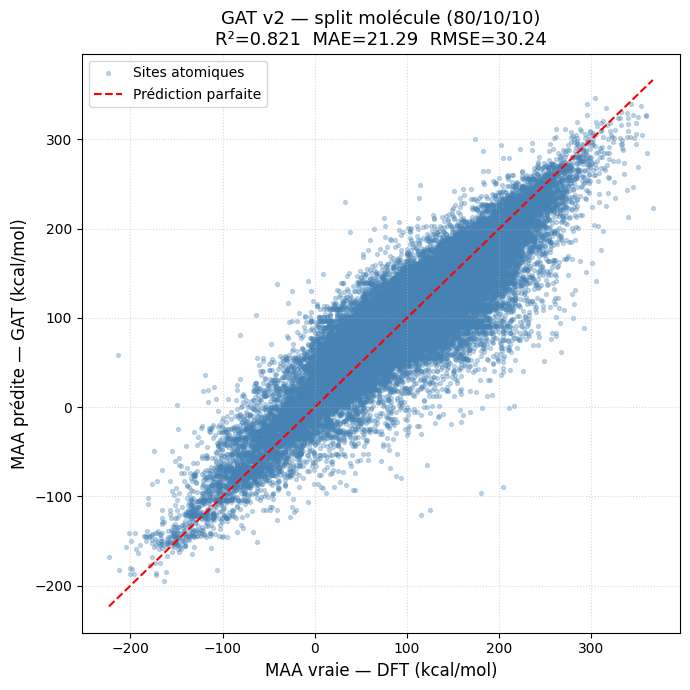


✅ Résultats exportés dans : C:\Users\felic\Downloads\outputs_gat


In [ ]:
# ── Evaluation on the test set ───────────────────────────────────────────────
checkpoint = torch.load(out_dir / 'best_gat_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
MAA_MEAN = checkpoint['y_mean']
MAA_STD  = checkpoint['y_std']
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out  = model(data)
        all_preds.extend(out.view(-1).cpu().numpy())
        all_targets.extend(data.y.cpu().numpy())

all_preds   = np.array(all_preds)   * MAA_STD + MAA_MEAN
all_targets = np.array(all_targets) * MAA_STD + MAA_MEAN

r2   = r2_score(all_targets, all_preds)
mae  = mean_absolute_error(all_targets, all_preds)
rmse = math.sqrt(mean_squared_error(all_targets, all_preds))

print("\n" + "="*50)
print("  📊 GAT RESULTS (molecule split, aligned data)")
print("="*50)
print(f"  R²   : {r2:.4f}")
print(f"  MAE  : {mae:.4f} kcal/mol")
print(f"  RMSE : {rmse:.4f} kcal/mol")
print("="*50)
print(f"  Test molecules: {test_df['canon_smiles'].nunique()}")
print(f"  Test sites    : {len(test_list)}")

# ── Parity plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 7))
plt.scatter(all_targets, all_preds, alpha=0.3, s=8, color='steelblue', label='Atomic sites')
lims = [min(all_targets.min(), all_preds.min()),
        max(all_targets.max(), all_preds.max())]
plt.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('True MAA — DFT (kcal/mol)', fontsize=12)
plt.ylabel('Predicted MAA — GAT (kcal/mol)', fontsize=12)
plt.title(f'GAT v2 — molecule split (80/10/10)\n'
          f'R²={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}', fontsize=13)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(out_dir / 'parity_plot_gat.png', dpi=200)
plt.show()

# ── Export predictions (same format as MPNN) ─────────────────────────────────
import pandas as pd
pred_df = pd.DataFrame({'MAA_true': all_targets, 'MAA_pred': all_preds,
                        'abs_error': np.abs(all_preds - all_targets)})
pred_df.to_csv(out_dir / 'test_predictions_gat.csv', index=False)
print(f"\n✅ Results exported to: {out_dir.resolve()}")
